In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# using cloned code from https://github.com/facebookresearch/detr
# adding the dir to PYTHONPATH didn't work for some reason, some classes would import but others would not hence this nasty hack

from detr.models.transformer import TransformerEncoder, TransformerDecoder, TransformerEncoderLayer, TransformerDecoderLayer
from detr.models.transformer import Transformer as DETRTransformer
from detr.models.position_encoding import PositionEmbeddingSine, PositionEmbeddingLearned, NestedTensor
import json
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) # Si bel, basta warning. Hanno rotto il cazzo



In [4]:
import torch
import numpy as np
import pickle
import argparse
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm import tqdm
from einops import rearrange
import copy

#from act.utils import sample_box_pose, sample_insertion_pose # robot functions
#from act.visualize_episodes import save_videos

from pdb import set_trace
import matplotlib.pyplot as plt
import math
from typing import Optional, List
import h5py
from torch.utils.data import DataLoader
from pathlib import Path

import torch.nn as nn
from torch.nn import functional as F
import torchvision
import torchvision.transforms as transforms
from torch import nn, Tensor

#from act.sim_env import make_sim_env, BOX_POSE
from aim import Run
from liralab.model import *

In [5]:
dry_run = False
run = Run(experiment="imitate_episodes", repo='dry_run' if dry_run else None)
run["hparams"] = args

# Data Loading

The next cell can be safely glossed over -- we look at the data the model is seeing below it.

In the next cell we are dealing with the intricacies of loading the data from `hdf` files which might not be all that relevant.

In [6]:
class EpisodicDataset(torch.utils.data.Dataset):
    def __init__(self, episode_ids):
        self.episode_ids = episode_ids
        self.norm_stats = get_norm_stats()
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        print("MEAN: ", self.norm_stats['qpos_mean'])
        print("STD: ", self.norm_stats['qpos_std'])

    def __len__(self):
        return len(self.episode_ids)

    def __getitem__(self, index):
        episode_id = self.episode_ids[index]
        dataset_path = os.path.join(args['dataset_dir'], f'episode_{episode_id}.hdf5')
        
        with h5py.File(dataset_path, 'r') as root:
            is_sim = root.attrs['sim']  # given what I'm planning, I will not need this flag
            is_sim = True
            episode_len = root['/action'].shape[0]  # 400
            
            start_ts = np.random.choice(episode_len)
            # get observation at start_ts only
            qpos = root['/observations/qpos'][start_ts]
            qvel = root['/observations/qvel'][start_ts]
            image_dict = dict()
            for cam_name in args['camera_names']:
                image_dict[cam_name] = root[f'/observations/images/{cam_name}'][start_ts]
            # get all actions after and including start_ts
            if is_sim:
                action = root['/action'][start_ts:]
                action_len = episode_len - start_ts
            else:
                # I have no clue why this branch of the if statement exists?!
                # maybe this is some artifact of how the data was captured...
                # if there is a delay in reading qpos... then winding actions by 0.02s might make sense
                # this is perplexing but I will leave this here in case it is useful in the future...
                action = root['/action'][max(0, start_ts - 1):] # hack, to make timesteps more aligned
                action_len = episode_len - max(0, start_ts - 1) # hack, to make timesteps more aligned

        self.is_sim = is_sim
        padded_action = np.zeros((episode_len, args['action_dim']), dtype=np.float32)
        padded_action[:action_len] = action
        is_pad = np.zeros(episode_len)
        is_pad[action_len:] = 1

        all_cam_images = np.stack([image_dict[cam_name] for cam_name in args['camera_names']], axis=0)

        # construct observations
        image_data = torch.from_numpy(all_cam_images).float()
        qpos_data = torch.from_numpy(qpos).float()
        action_data = torch.from_numpy(padded_action).float()
        is_pad = torch.from_numpy(is_pad).bool()

        # channel last
        image_data = torch.einsum('k h w c -> k c h w', image_data)
        # image_data[:,0,:,:] *= 0

        # normalize image and change dtype to float
        image_data /= 255.0
        image_data = self.normalize(image_data)
        action_data = (action_data - self.norm_stats["action_mean"]) / self.norm_stats["action_std"]
        qpos_data = (qpos_data - self.norm_stats["qpos_mean"]) / self.norm_stats["qpos_std"]
        return image_data[0], qpos_data, action_data, is_pad


def get_norm_stats():
    dataset_dir = Path(args['dataset_dir'])
    hdf5_files = list(dataset_dir.glob("*.hdf5"))
    all_qpos_data = []
    all_action_data = []
    for episode_path in hdf5_files:
        # dataset_path = os.path.join(dataset_dir, f'episode_{episode_idx}.hdf5')
        with h5py.File(episode_path, 'r') as root:
            qpos = root['/observations/qpos'][()]
            qvel = root['/observations/qvel'][()]
            action = root['/action'][()]
        all_qpos_data.append(torch.from_numpy(qpos))
        all_action_data.append(torch.from_numpy(action))
    all_qpos_data = torch.stack(all_qpos_data)
    all_action_data = torch.stack(all_action_data)
    all_action_data = all_action_data

    # normalize action data
    action_mean = all_action_data.mean(dim=[0, 1], keepdim=True)
    action_std = all_action_data.std(dim=[0, 1], keepdim=True)
    action_std = torch.clip(action_std, 1e-2, np.inf) # clipping

    # normalize qpos data
    qpos_mean = all_qpos_data.mean(dim=[0, 1], keepdim=True)
    qpos_std = all_qpos_data.std(dim=[0, 1], keepdim=True)
    qpos_std = torch.clip(qpos_std, 1e-2, np.inf) # clipping

    stats = {"action_mean": action_mean.numpy().squeeze(), "action_std": action_std.numpy().squeeze(),
             "qpos_mean": qpos_mean.numpy().squeeze(), "qpos_std": qpos_std.numpy().squeeze(),
             "example_qpos": qpos}

    return stats


def load_data(num_episodes, camera_names, batch_size_train, batch_size_val):
    print(f"\nData from: {args['dataset_dir']}\n")
    print("Episodes count: " + str(num_episodes))
    # obtain train test split
    train_ratio = 0.8
    shuffled_indices = np.random.permutation(num_episodes)
    train_indices = shuffled_indices[:int(train_ratio * num_episodes)]
    val_indices = shuffled_indices[int(train_ratio * num_episodes):]

    print(f"TRAIN: {train_indices}\nVAL: {val_indices}")

    # construct dataset and dataloader
    train_dataset = EpisodicDataset(train_indices)
    val_dataset = EpisodicDataset(val_indices)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True, pin_memory=True, num_workers=1, prefetch_factor=1)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=True, pin_memory=True, num_workers=1, prefetch_factor=1)

    return train_dataloader, val_dataloader


In [7]:
def TRYGET():
    episode_id = 1
    dataset_path = os.path.join(args['dataset_dir'], f'episode_{episode_id}.hdf5')
        
    with h5py.File(dataset_path, 'r') as root:
        print(list(root.attrs.keys()))
        def show(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"{name} ----------| shape={obj.shape} |---------- dtype={obj.dtype}")

        root.visititems(show)

        is_sim = root.attrs['sim']  # given what I'm planning, I will not need this flag
        is_sim = True
        episode_len = root['/action'].shape[0]  # 400
        
        print(root['action'][5])
        print(root['observations/qpos'][6])
TRYGET()

['sim']
action ----------| shape=(600, 6) |---------- dtype=float32
observations/images/top ----------| shape=(600, 256, 256, 3) |---------- dtype=uint8
observations/qpos ----------| shape=(600, 9) |---------- dtype=float32
observations/qvel ----------| shape=(600, 7) |---------- dtype=float32
[ 5.3414691e-04 -2.5786745e-04  9.1005553e-04 -7.4037176e-04
 -1.7231026e-03  6.6297980e-05]
[ 5.3414691e-04 -2.5786745e-04  9.1005553e-04 -7.4037176e-04
 -1.7231026e-03  6.6297980e-05  4.9813899e-01  1.1203700e+00
 -5.8303871e+00]


In [8]:
train_dataloader, val_dataloader = load_data(
    args['num_episodes'],
    args['camera_names'],
    batch_size_train=args['batch_size'],
    batch_size_val=args['batch_size']
)


Data from: data/liralab/AAA/

Episodes count: 12
TRAIN: [ 6  5  9  2  8  3  1  7 11]
VAL: [ 0 10  4]
MEAN:  [ 1.5138870e-02 -1.7349826e-02  1.5937053e-02 -2.8640807e-03
 -1.7311318e-02 -3.3743221e-02 -9.8324761e-02  1.3569747e+00
 -6.5763698e+00]
STD:  [0.01058191 0.01974562 0.01       0.04358718 0.02709208 0.0695556
 1.6383007  1.4016365  5.6140966 ]
MEAN:  [ 1.5138870e-02 -1.7349826e-02  1.5937053e-02 -2.8640807e-03
 -1.7311318e-02 -3.3743221e-02 -9.8324761e-02  1.3569747e+00
 -6.5763698e+00]
STD:  [0.01058191 0.01974562 0.01       0.04358718 0.02709208 0.0695556
 1.6383007  1.4016365  5.6140966 ]


In [9]:
images, qpos, actions, is_pad = next(iter(train_dataloader))

In [10]:
print(images.shape)
print(qpos.shape)
print(actions.shape)
print(is_pad.shape)
print(qpos[0])
print(actions[0][0])

torch.Size([9, 3, 256, 256])
torch.Size([9, 9])
torch.Size([9, 600, 6])
torch.Size([9, 600])
tensor([ 0.5141, -0.8969,  0.9124, -0.9095, -0.4609, -0.5215,  0.3133,  1.8050,
        -0.9635])
tensor([ 0.5027, -0.9470,  0.9068, -0.9194, -0.4490, -0.5515])


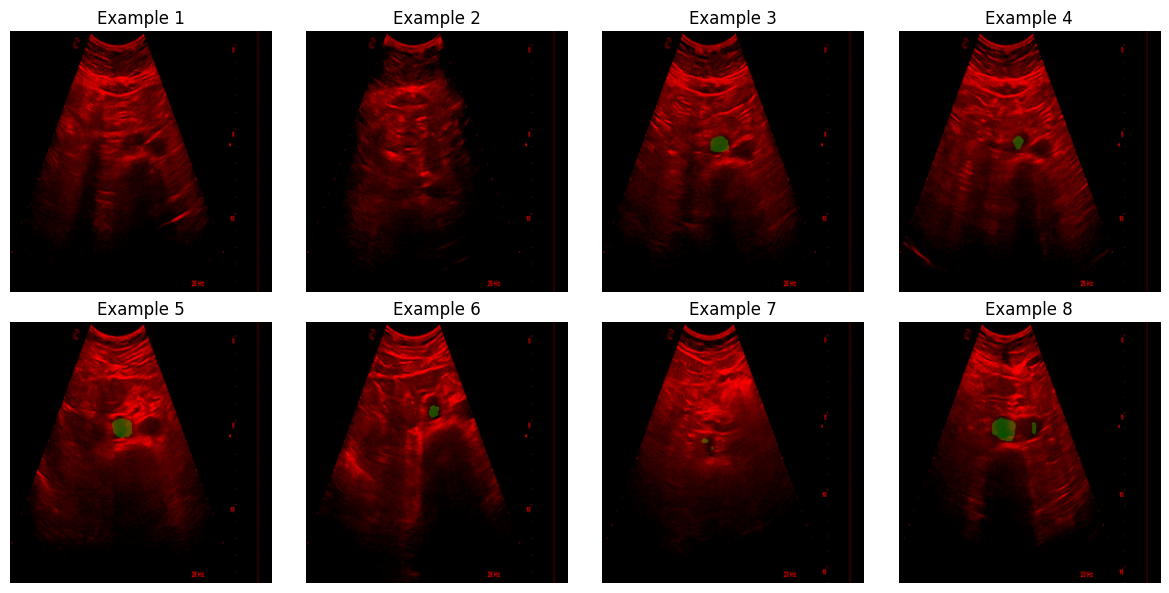

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
axes = axes.flatten()

for i in range(images.size(0)):
    if i >= 8: continue
    image = images[i].squeeze(0)
    image *= np.array([0.229, 0.224, 0.225])[:, None, None]
    image += np.array([0.485, 0.456, 0.406])[:, None, None]
    image = image.permute(1, 2, 0).numpy().clip(0,1)
    axes[i].imshow(image)
    axes[i].axis('off')  # Remove the axis labels and ticks
    axes[i].set_title(f'Example {i+1}')

plt.tight_layout()
plt.show()

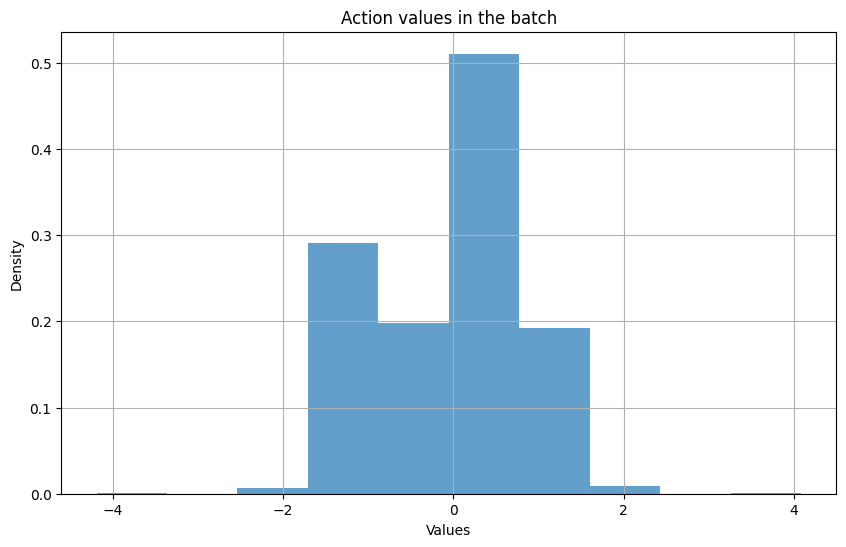

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(actions.reshape(1, -1).numpy()[0], bins=10, density=True, alpha=0.7)
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Action values in the batch')
plt.grid(True)
plt.show()

In [13]:
stats = train_dataloader.dataset.norm_stats
stats['action_mean']/stats['action_std']

array([ 1.4306372 , -0.878667  ,  1.5937053 , -0.06570923, -0.6389808 ,
       -0.48512584], dtype=float32)

In [14]:
os.makedirs(args['trained_model_dir'], exist_ok=True)

stats_path = os.path.join(args['trained_model_dir'], 'dataset_stats.pkl')
with open(stats_path, 'wb') as f:
    pickle.dump(train_dataloader.dataset.norm_stats, f)

with open(f"{args['trained_model_dir']}args.json", "w") as f:
    json.dump(args, f, indent=4)

![ACT Overview](ACT_overview.png)

The `forward` method of the `Transformer` is hard to understand at first sight. Why do we pass `queries` as `query_pos` which seems to suggest that they are positional encodings?

If we look at the multiheaded attention (a `nn.MultiheadAttention`) of the DETR `TransformerDecoderLayer`,  this becomes more clear:
```
tgt2 = self.multihead_attn(query=self.with_pos_embed(tgt, query_pos),
                           key=self.with_pos_embed(memory, pos),
                           value=memory, attn_mask=memory_mask,
                           key_padding_mask=memory_key_padding_mask)[0]
```

The `self.with_pos_embed(...)` sums its arguments so in the first `TransformerDecoderLayer` of `TransformerDecoder` query is just `query_pos` (query embeddings).

In a sense query embeddings are positional embeddings -- the only information they carry is what value to be outputted for the `chunk_size` number of actions we are predicting.

In a standard transformer operating on text, queries would be obtained from summing positional encoding (`query_pos`) with the embedding of the word at current time step `t` and as the embedding travels up the transformer stack, we would hope that it would transform into a vector containing information that would lend itself well to predicitng the word idx for word at time step `t+1`.

The following excerpt from [Attention is all you need](https://arxiv.org/abs/1706.03762) describes how this is done:
```
In "encoder-decoder attention" layers, the queries come from the previous decoder layer,
and the memory keys and values come from the output of the encoder. This allows every
position in the decoder to attend over all positions in the input sequence. This mimics the
typical encoder-decoder attention mechanisms in sequence-to-sequence models such as
[38, 2, 9].
```

`keys` and `values` come from the decoder, as we would expect.

Unless I am missing something, `queries` could be passed as `tgt` to decoder. That is what the image depicting ACT would suggest.

But it is much tougher to backpropagate gradient through the decoder layers all the way to the bottom. Here, using queries as position embeddings for a target of all zeroes means we are getting a residual connection at every decoder layer for free! Without modifying the original code. That is quite ingenious.

But if we look at DETR the image there, likewise, positions the queries where we would expect in
puts to the decoder, where shifted input would normally go!

Here is the architecture from Attention is all you need, for reference.
![attention is all you need](attention_is_all_you_need.png)

And here is a portrayal of DETR:
![DETR](DETR.png)

So while the images are very suggestive, they only partially capture how queries are used! Explained in [the DETR paper](https://arxiv.org/abs/2005.12872) and more explicitly via looking at what information gets passed where in code:

```
These input embeddings are learnt positional encodings that we refer to as object queries,
and similarly to the encoder, we add them to the input of each attention layer.
```

In [15]:
policy = ACTPolicy()

print(f"KL Weight {args['kl_weight']}")

n_parameters = sum(p.numel() for p in policy.model.parameters() if p.requires_grad)
print("number of parameters: %.2fM" % (n_parameters/1e6))

/home/legion/PycharmProjects/ACT/ACT_refactor/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/legion/PycharmProjects/ACT/ACT_refactor/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


KL Weight 100
number of parameters: 118.41M


In [16]:
normalize_fn = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def get_image(ts, camera_names):
    curr_images = []
    for cam_name in camera_names:
        curr_image = rearrange(ts.observation['images'][cam_name], 'h w c -> c h w')
        curr_images.append(curr_image)
    curr_image = np.stack(curr_images, axis=0)
    curr_image = torch.from_numpy(curr_image / 255.0).float().cuda().unsqueeze(0)
    curr_image = normalize_fn(curr_image)
    return curr_image[0]

def run_rollout_validation(ckpt_name='policy_best.ckpt', num_rollouts=20, query_frequency=20, save_video=False):
    policy = ACTPolicy()
    policy.load_state_dict(
        torch.load(os.path.join(args['trained_model_dir'], ckpt_name)
        )
    )
    policy.cuda()
    policy.eval()

    stats_path = os.path.join(args['trained_model_dir'], 'dataset_stats.pkl')
    with open(stats_path, 'rb') as f:
        stats = pickle.load(f)
    
    pre_process = lambda s_qpos: (s_qpos - stats['qpos_mean']) / stats['qpos_std']
    post_process = lambda a: a * stats['action_std'] + stats['action_mean']
    
    
    env = make_sim_env(args['task_name'])
    env_max_reward = env.task.max_reward

    max_timesteps = args['episode_len']

    episode_returns = []
    highest_rewards = []
    
    for rollout_id in range(num_rollouts):
        ### set task
        if 'sim_transfer_cube' in args['task_name']:
            BOX_POSE[0] = sample_box_pose() # used in sim reset
        elif 'sim_insertion' in args['task_name']:
            BOX_POSE[0] = np.concatenate(sample_insertion_pose()) # used in sim reset
    
        ts = env.reset()
    
        ### evaluation loop
        qpos_history = torch.zeros((1, max_timesteps, args['state_dim'])).cuda()
        image_list = [] # for visualization
        qpos_list = []
        target_qpos_list = []
        rewards = []
        with torch.inference_mode():
            for t in range(max_timesteps):
                ### process previous timestep to get qpos and image_list
                obs = ts.observation
                if 'images' in obs:
                    image_list.append(obs['images'])
                else:
                    image_list.append({'main': obs['image']})
                qpos = pre_process(obs['qpos'])
                qpos = torch.from_numpy(qpos).float().cuda().unsqueeze(0)
                qpos_history[:, t] = qpos
                curr_image = get_image(ts, args['camera_names'])
    
                ### query policy
                if t % query_frequency == 0:
                    all_actions = policy(qpos, curr_image)
                raw_action = all_actions[:, t % query_frequency]
    
                ### post-process actions
                raw_action = raw_action.squeeze(0).cpu().numpy()
                action = post_process(raw_action)
                target_qpos = action
    
                ### step the environment
                ts = env.step(target_qpos)
    
                ### for visualization
                qpos_list.append(qpos)
                target_qpos_list.append(target_qpos)
                rewards.append(ts.reward)
            plt.close()
    
            rewards = np.array(rewards)
            episode_return = np.sum(rewards[rewards!=None])
            episode_returns.append(episode_return)
            episode_highest_reward = np.max(rewards)
            highest_rewards.append(episode_highest_reward)
            print(f'Rollout {rollout_id}\n{episode_return=}, {episode_highest_reward=}, {env_max_reward=}, Success: {episode_highest_reward==env_max_reward}')
    
            if rollout_id == 0 and save_video:
                save_videos(image_list, 1/args['fps'], video_path=os.path.join(args['trained_model_dir'], 'rollout_0.mp4'))
    
            success_rate = np.mean(np.array(highest_rewards) == env_max_reward)
            avg_return = np.mean(episode_returns)
            summary_str = f'\nSuccess rate: {success_rate}\nAverage return: {avg_return}\n\n'
            for r in range(env_max_reward+1):
                more_or_equal_r = (np.array(highest_rewards) >= r).sum()
                more_or_equal_r_rate = more_or_equal_r / num_rollouts
                summary_str += f'Reward >= {r}: {more_or_equal_r}/{num_rollouts} = {more_or_equal_r_rate*100}%\n'
        
    return success_rate, avg_return

In [17]:
print(torch.cuda.is_available())
policy.cuda()

param_dicts = [
    {"params": [p for n, p in policy.model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in policy.model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": args['lr_backbone'],
    },
]
optimizer = torch.optim.AdamW(param_dicts, lr=args['lr'], weight_decay=args['weight_decay'])

min_val_loss = np.inf
best_ckpt_info = None
all_losses_val = []
all_losses_train = []
for epoch in tqdm(range(args['num_epochs'])):
    # validation
    with torch.inference_mode():
        policy.eval()
        losses = []
        losses_val = []
        for image_data, qpos_data, action_data, is_pad in val_dataloader:
            image_data, qpos_data, action_data, is_pad = image_data.cuda(), qpos_data.cuda(), action_data.cuda(), is_pad.cuda()
            loss = policy(qpos_data, image_data, action_data, is_pad)
            losses_val.append(loss.cpu().numpy())
            all_losses_val.append(loss.cpu().numpy())

        epoch_val_loss = np.mean(losses_val)
        if epoch_val_loss < min_val_loss:
            min_val_loss = epoch_val_loss
            best_ckpt_info = (epoch, min_val_loss, deepcopy(policy.state_dict()))

    run.track(epoch_val_loss, name='loss', step=epoch, context={ "subset":"val" })

    # training
    policy.train()
    optimizer.zero_grad()
    for image_data, qpos_data, action_data, is_pad in train_dataloader:
        image_data, qpos_data, action_data, is_pad = image_data.cuda(), qpos_data.cuda(), action_data.cuda(), is_pad.cuda()
        loss = policy(qpos_data, image_data, action_data, is_pad)
        losses.append(loss.cpu().detach().numpy())
        all_losses_train.append(loss.cpu().detach().numpy())

        # backward
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if(epoch % args['eval_interval_epochs'] == 0):
        print(f'\nEpoch {epoch}')
        print(f'Train loss:   {np.mean(losses):.5f}')
        print(f'Val loss:   {epoch_val_loss:.5f}')

    run.track(loss.item(), name='loss', step=epoch, context={ "subset":"train" })

    if epoch != 0 and (epoch % args['eval_interval_epochs'] == 0 or epoch == args['num_epochs']-1):
        ckpt_name = f'policy_epoch_{epoch}.ckpt'
        ckpt_path = os.path.join(args['trained_model_dir'], ckpt_name)
        torch.save(policy.state_dict(), ckpt_path)
        

        #success_rate, avg_return = run_rollout_validation( f'policy_epoch_{epoch}.ckpt', num_rollouts=args['num_eval_rollouts'])
        #print(f'{ckpt_name}: {success_rate=} {avg_return=}')
        
        #run.track(success_rate, name='success_rate', step=epoch)
        #run.track(avg_return, name='average_return', step=epoch)

ckpt_path = os.path.join(args['trained_model_dir'], f'policy_last.ckpt')
torch.save(policy.state_dict(), ckpt_path)

best_epoch, min_val_loss, best_state_dict = best_ckpt_info
ckpt_path = os.path.join(args['trained_model_dir'], f'policy_epoch_{best_epoch}.ckpt')
torch.save(best_state_dict, ckpt_path)
print(f'Training finished: val loss {min_val_loss:.6f} at epoch {best_epoch}')

True


  0%|          | 1/6000 [00:00<1:10:42,  1.41it/s]


Epoch 0
Train loss:   3253.36963
Val loss:   3430.09229


  8%|▊         | 500/6000 [01:29<16:53,  5.43it/s]


Epoch 500
Train loss:   128.01466
Val loss:   10.96449


...


Epoch 5000
Train loss:   22.15069
Val loss:   2.73898


 92%|█████████▏| 5500/6000 [17:14<01:38,  5.05it/s]


Epoch 5500
Train loss:   19.52351
Val loss:   3.27117


100%|██████████| 6000/6000 [18:50<00:00,  5.31it/s]


Training finished: val loss 1.469494 at epoch 5985


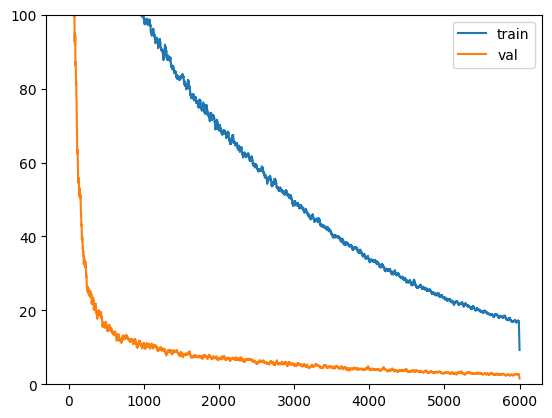

In [18]:
def low_pass_filter(x, window_size=10):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')

v_f = low_pass_filter(all_losses_val, window_size=20)
t_f = low_pass_filter(all_losses_train, window_size=20)

plt.figure()
plt.plot(t_f, label="train")
plt.plot(v_f, label="val")

plt.ylim(0, 100)

plt.legend()
plt.savefig(f"{args["trained_model_dir"]}loss_plot.png", dpi=300)

plt.show()

In [19]:
run.close()